# **Explainable Credit Risk Assessment**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Load the Data

df=pd.read_csv('/content/credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [ ]:
# Missing or Null Values
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
# Target Balance

df['loan_status'].unique()

array([1, 0])

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

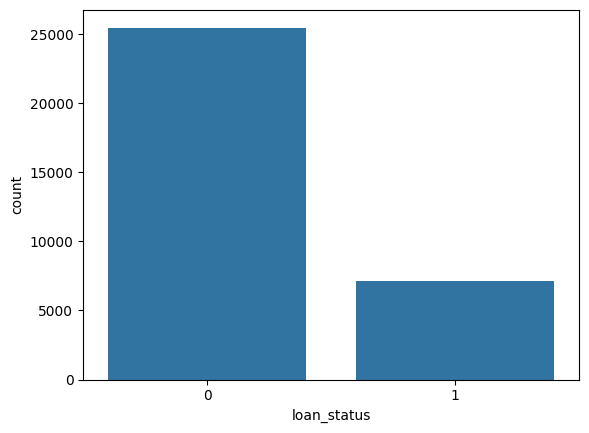

In [ ]:
sns.countplot(x='loan_status',data=df)

In [ ]:
# Outliers Check

df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


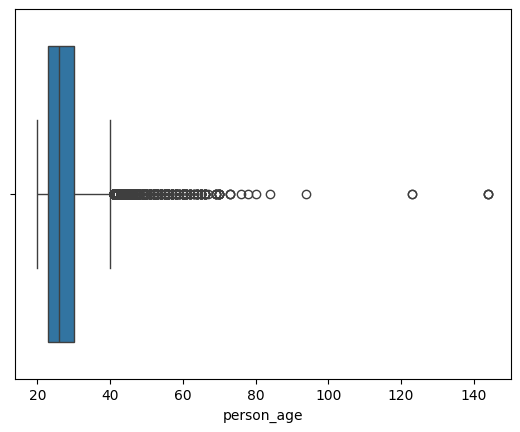

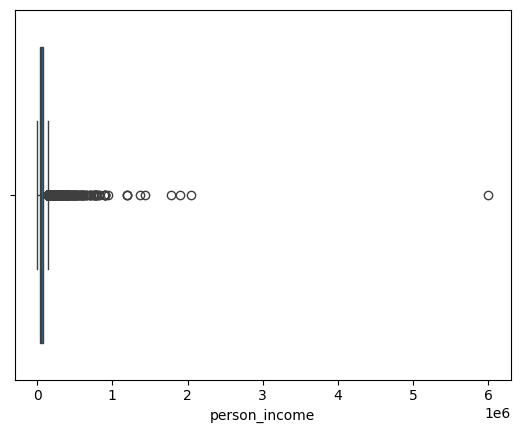

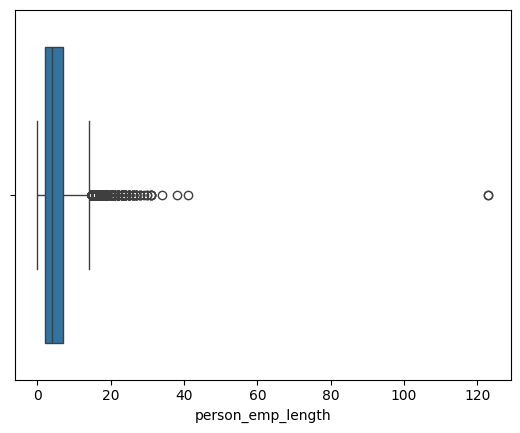

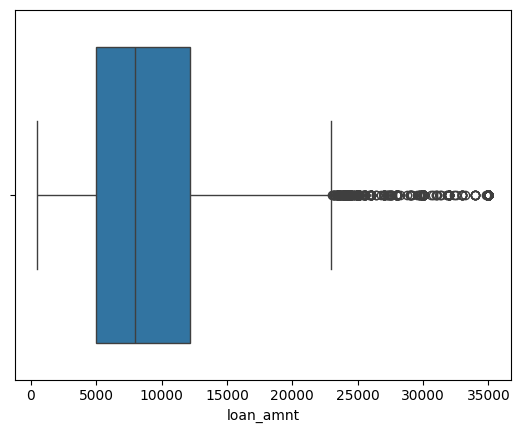

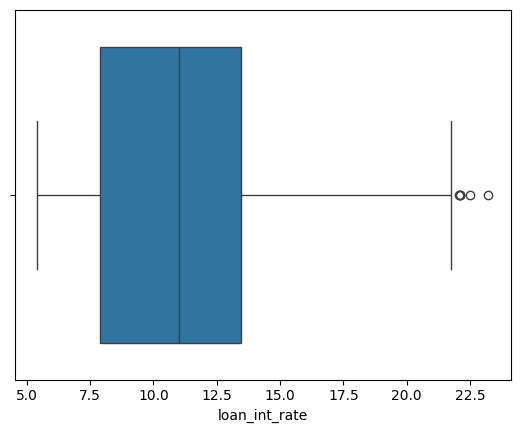

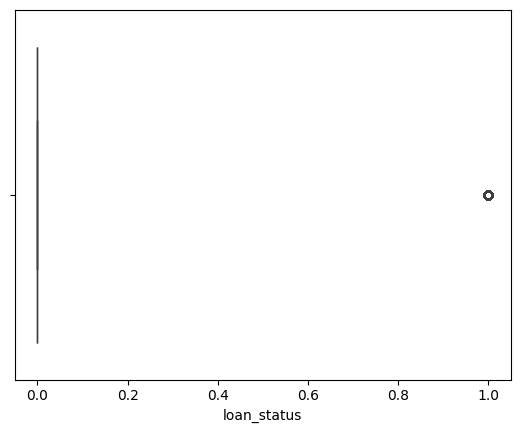

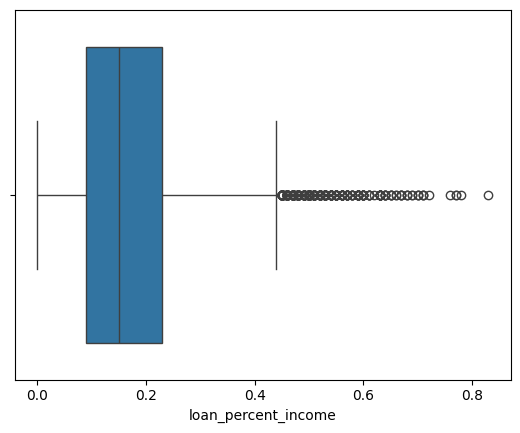

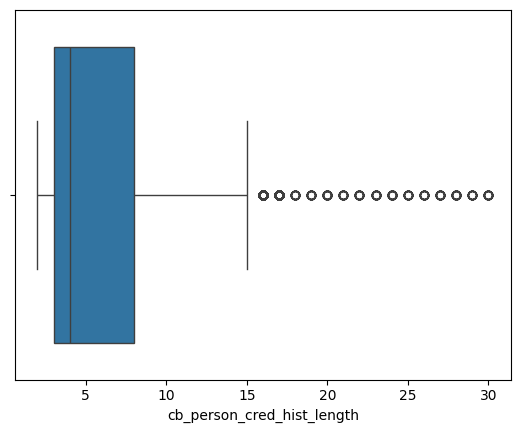

In [ ]:
numerical_col=df.select_dtypes(include='number').columns
numerical_col

for i in numerical_col:
  sns.boxplot(x=df[i])
  plt.show()

In [ ]:
# Check those persons, have age greater than 100

(df['person_age'] > 100).sum()

np.int64(5)

In [ ]:
# Check those persons, have employee length greater than 60

(df['person_emp_length'] > 60).sum()

np.int64(2)

<Axes: >

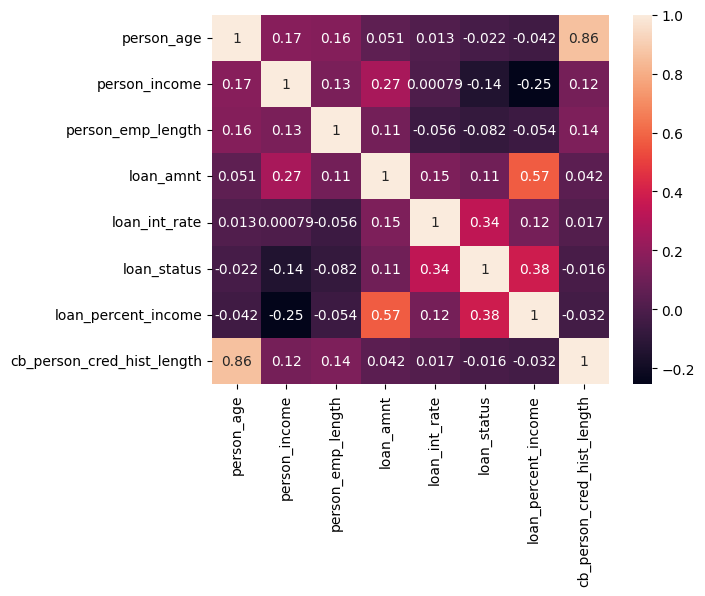

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **Data Validation and Outlier handling**

In [ ]:
df_copy=df.copy()

# Remove Duplicates

print(f"Orginal Rows {df_copy.shape}")
df_copy.drop_duplicates(inplace=True)
print(f"After Remove Duplicated Rows {df_copy.shape}")


# Remove Age below 18 and above 100

df_copy=df_copy[df['person_age']>=18]
df_copy=df_copy[df['person_age']<=100]

# Remove emplyement length greater than age or extreme outliers (>60)

df_copy=df_copy[df_copy['person_emp_length']<=df_copy['person_age']]
df_copy=df_copy[df_copy['person_emp_length']<=60]

# Remove the rows with zero or negative income and loan amount.

df_copy=df_copy[df_copy['loan_amnt'] > 0]

# check if the loan intrest rate looks realistic.

print("Loan Intrest range from (min: 5.42 and max:23.22 )")

Orginal Rows (32581, 12)
After Remove Duplicated Rows (32416, 12)
Loan Intrest range from (min: 5.42 and max:23.22 )


/tmp/ipykernel_989/2002579633.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy=df_copy[df['person_age']>=18]
/tmp/ipykernel_989/2002579633.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy=df_copy[df['person_age']<=100]


In [ ]:
numerical_col
# df_copy.describe()

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

# **Features,Target and Train-Test Split**

In [ ]:
# Stratify=y means ke y de vich {1,0} hai te 1 da kuj part training lyi jnda te kuj part testing lyi
# usi tarah 0 da kuj part training lyi jnda te kuj part testing lyi te sanu ho equally bhejn lyi stratify use krde aa

x=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
numerical_col=['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']

categorical_col=['person_home_ownership','loan_intent','loan_grade']

# **Handle Class Imbalacement**

In [ ]:
# class imbalance means ke upper 0 bhaut vaar aa reha siga as comparison 1 so this is class imbalance
# model 0 lyi bias ho jayega te shi perdform nhi kr payega


# class imbalancement nu handle krn lyi aasi class -> weight da use krde aa eh model nu kehnda va ki eh class nu vi dekho jihan da perportion ghat hai

# they will assign weights

In [ ]:
y_train.value_counts()

neg,pos=np.bincount(y_train)
scale_weight=neg/pos

In [ ]:
scale_weight

np.float64(3.6312213039485766)

# **Data Preprocessing -> Pipeline and Column Transformer**

In [ ]:
# Logistic Regression : use Impute + Scale Numeric, Impute means agar null values aa jndi hai feature ch tah ohnu handle krn lyi median imputation use krange
# impute + onehotencoding for categorical columns

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor_lr=ColumnTransformer(
    transformers=[
        # Numerical Column
        ('num',Pipeline(
            steps=[
                ('impute',SimpleImputer(strategy='median')),
                ('scaler',StandardScaler())
            ]
        ),numerical_col),
        # Categorical Column
        ('cat',Pipeline(
            steps=[
                ('impute',SimpleImputer(strategy='constant',fill_value='Missing')),
                ('onehot',OneHotEncoder(handle_unknown='ignore'))
            ]
        ),categorical_col)
    ]
)

In [ ]:
# Processing For XGBOOST : Impute Numeric Only (No Scaling) , impute + one hot encoding

preprocessor_xg=ColumnTransformer(
    transformers=[
        # Numerical Column
        ('num',Pipeline(
            steps=[
                ('impute',SimpleImputer(strategy='median'))
            ]
        ),numerical_col),
        # Categorical Column
        ('cat',Pipeline(
            steps=[
                ('impute',SimpleImputer(strategy='constant',fill_value='Missing')),
                ('onehot',OneHotEncoder(handle_unknown='ignore'))
            ]
        ),categorical_col)
    ]
)

# **Evaluation Helper Function**

In [ ]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

# **Satisfied Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold,cross_validate

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring={'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}




In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
])

lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent',
                                                   'loan_grade'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# XGboost
from xgboost import XGBClassifier

Xg_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

Xg_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
for cv_name, pipe in [
    ("Logistic Regression", lr_cv_pipeline),
    ("XGboost", Xg_cv_pipeline)
]:

    cv_result = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(cv_name)
    print(f'Roc_AUC:{cv_result['test_roc_auc'].mean()}')
    print(f'Accuracy:{cv_result['test_accuracy'].mean()}')
    print(f'Precision:{cv_result['test_precision'].mean()}')
    print(f'Recall:{cv_result['test_recall'].mean()}')
    print(f'F1:{cv_result['test_f1'].mean()}')
    print()

Logistic Regression
Roc_AUC:0.8705172305947023
Accuracy:0.8116742642929804
Precision:0.5449720080395224
Recall:0.7779614325068871
F1:0.6408437467975503

XGboost
Roc_AUC:0.9473309909873512
Accuracy:0.9192211139631367
Precision:0.8227566011601729
Recall:0.7981634527089072
F1:0.8100971397489758



In [ ]:
cv_result

{'fit_time': array([2.16452146, 2.16149879, 1.48411012, 1.4022789 , 0.71512365]),
 'score_time': array([0.32006907, 0.32960153, 0.16446519, 0.16046906, 0.09399319]),
 'test_roc_auc': array([0.94940788, 0.93765328, 0.94722644, 0.95168148, 0.95068587]),
 'test_accuracy': array([0.92149088, 0.91812054, 0.91850089, 0.91988895, 0.9181043 ]),
 'test_precision': array([0.82968601, 0.83732535, 0.81920904, 0.81860465, 0.80895795]),
 'test_recall': array([0.80073462, 0.77043159, 0.79889807, 0.80808081, 0.81267218]),
 'test_f1': array([0.81495327, 0.80248685, 0.80892608, 0.81330869, 0.81081081])}

# **Baseline Model : Logistic Regression**

In [ ]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(class_weight='balanced'))
])

baseline_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent',
                                                   'loan_grade'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



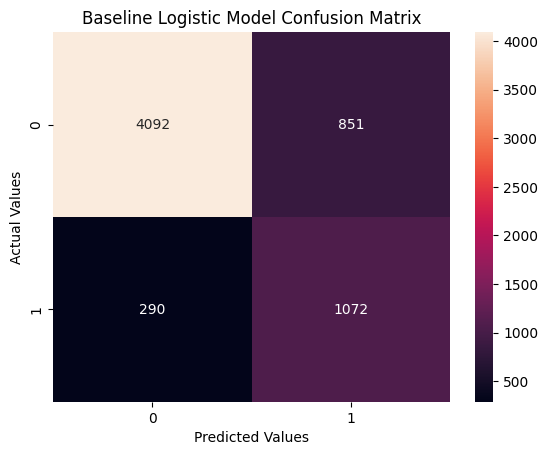

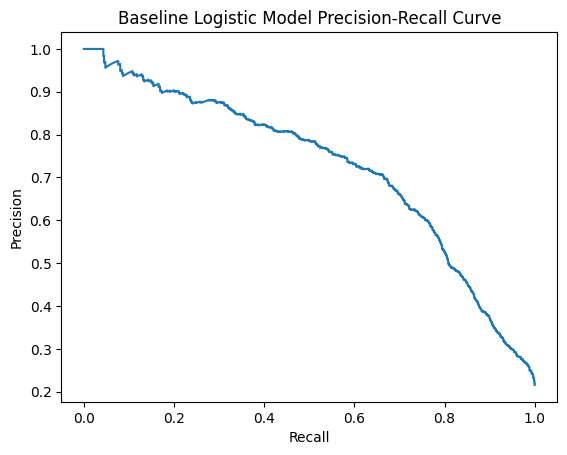

In [ ]:
# Evaluate Logistic MOdel

evaluate_model("Baseline Logistic Model",baseline_model,x_test,y_test)

# **XGboost Hyperparameter Tuning**

In [ ]:
xg_model=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weight,
        random_state=42))
])

xg_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Model Metrics:
Accuracy : 0.92
Precision : 0.81
Recall : 0.80
F1 : 0.81

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.81      0.80      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



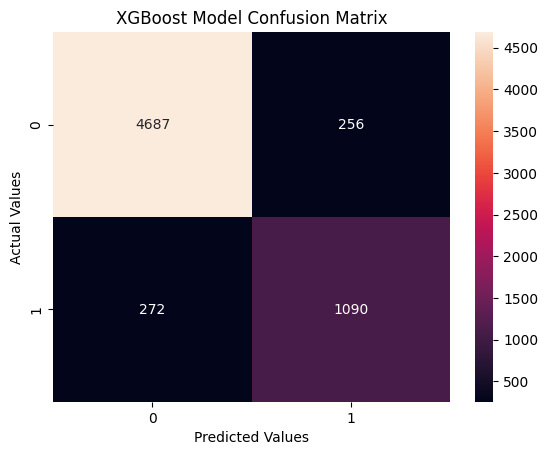

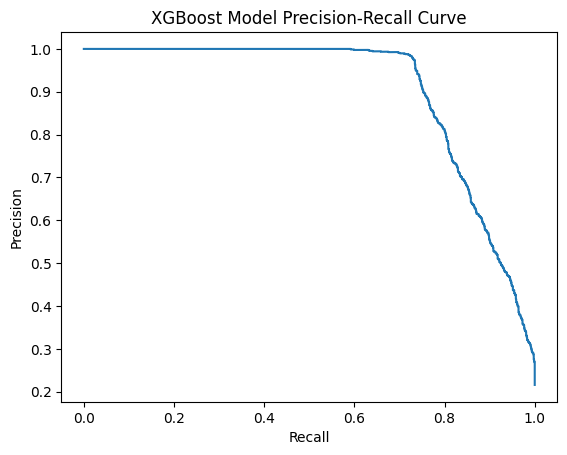

In [ ]:
evaluate_model("XGBoost Model",xg_model,x_test,y_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform

param_grid={
    "classifier__n_estimators":randint(150,600),
    "classifier__max_depth":randint(3,9),
    "classifier__learning_rate":uniform(0.01,0.5),
    "classifier__subsample":uniform(0.6,0.4), # Row Sampling
    "classifier__colsample_bytree":uniform(0.6,0.4),  # Column Sampling
    "classifier__min_child_weight":randint(1,10),
    "classifier__gamma":uniform(0,5)

}

# Lower gamma -> more splits -> complex Trees -> higher overfitting risk
# Higer gamma -> less splits -> simple Trees -> low overfitting risk

In [ ]:
random_search=RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=10,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length'...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b1104518a50>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b11051892b0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b11045b9590>},
                   scoring='average_precision', verbose=1)

In [ ]:
random_search.best_score_

np.float64(0.9012063097052904)

In [ ]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8941139831860874),
 'classifier__gamma': np.float64(1.6458711971327666),
 'classifier__learning_rate': np.float64(0.22702877750286354),
 'classifier__max_depth': 3,
 'classifier__min_child_weight': 2,
 'classifier__n_estimators': 521,
 'classifier__subsample': np.float64(0.8340054612837473)}

# **Compare Both Models Side by Side**

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



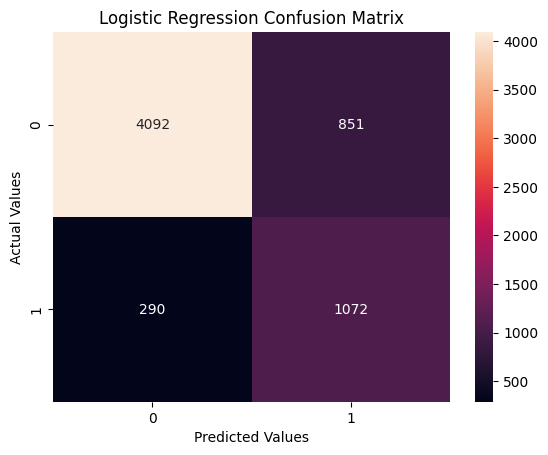

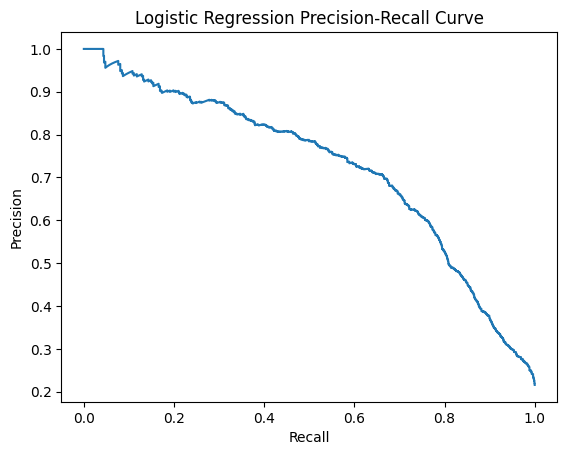

In [ ]:
evaluate_model("Logistic Regression", baseline_model, x_test, y_test)

XGBoost Metrics:
Accuracy : 0.91
Precision : 0.79
Recall : 0.81
F1 : 0.80

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      4943
           1       0.79      0.81      0.80      1362

    accuracy                           0.91      6305
   macro avg       0.87      0.88      0.87      6305
weighted avg       0.91      0.91      0.91      6305



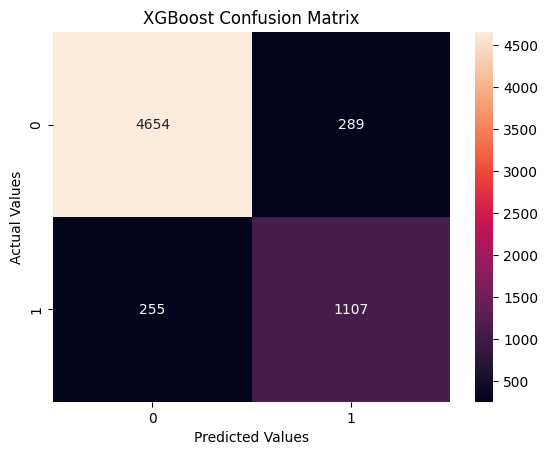

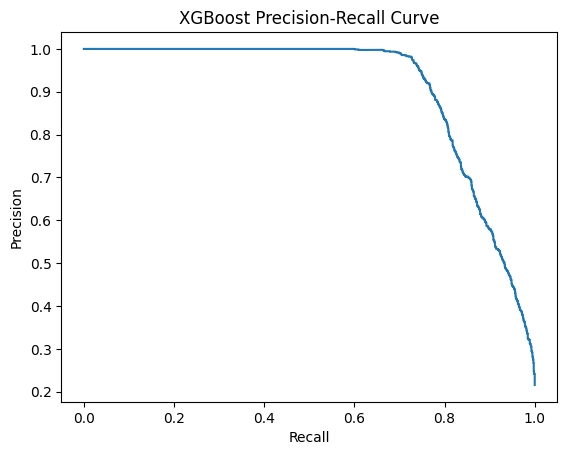

In [ ]:
#Passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model("XGBoost", random_search, x_test, y_test)

# **Optimizing the Classification Threshold**

XGBoost Model Metrics:
Used Threshold : 0.75
Accuracy : 0.94
Precision : 0.97
Recall : 0.73
F1 : 0.84

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.73      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



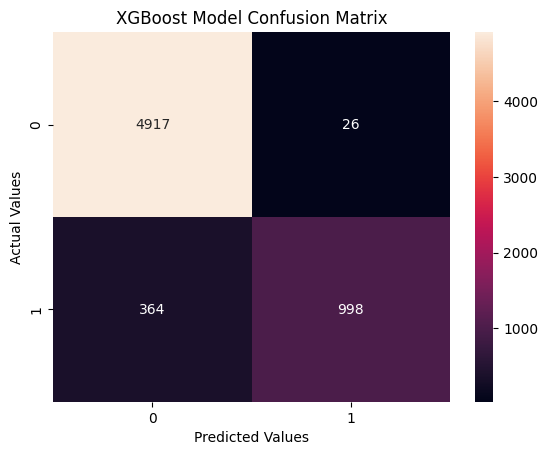

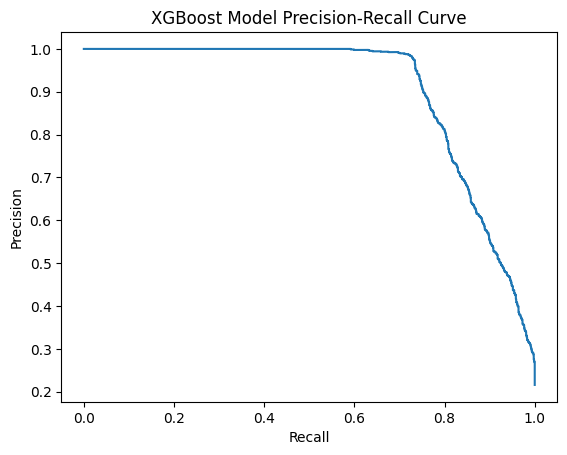

In [ ]:
prob=xg_model.predict_proba(x_test)[:,1]

#for each threshold calc. precison and recall

precisions , recalls , thresholds=precision_recall_curve(y_test,prob)

#calc. f1 score for each threshold

f1_scores=2*(precisions*recalls)/(precisions+recalls+1e-9)

#get the thresholdthat produces the highest f1 score

best=np.argmax(f1_scores[:-1])
best_threshold=thresholds[best]

#evaluate the xgboost model using that threshold

evaluate_model("XGBoost Model",xg_model,x_test,y_test,best_threshold)

# **Probability Calibration**

In [ ]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve. (Good for small data)
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature
"""

'\nMethods by which we can fix the poorly calibrated model.\n1. Platt Scaling/ Sigmoid -> Adjust the probabilites using a sigmoid curve.\n2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob. (non-linear calibartion)\n3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature\n'

In [ ]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)
calibrated_model.fit(x_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(f...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.22702877750286354),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=3,
                                                                max_leaves=None,
                                                                min_child_weight=2,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=521,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [ ]:
uncalibrated = xg_model.predict_proba(x_test)[:,1]  # uncalibrated model is xg model or raw model
calibrated = calibrated_model.predict_proba(x_test)[:,1]

In [ ]:
uncalibrated

array([0.8778091 , 0.17179687, 0.97675896, ..., 0.4795118 , 0.07335159,
       0.05800938], dtype=float32)

In [ ]:
calibrated

array([0.69179818, 0.02518682, 0.93316791, ..., 0.4500767 , 0.0300003 ,
       0.01372891])

In [ ]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)


actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

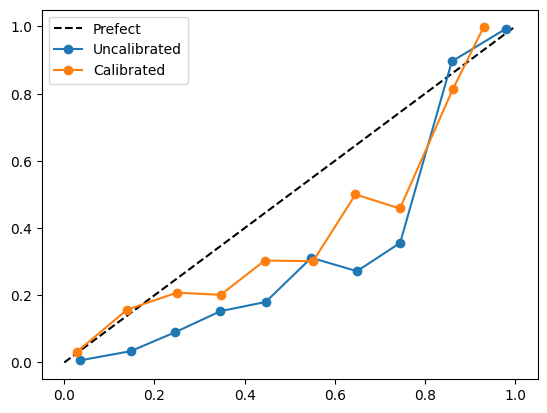

In [ ]:
#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()


# **Shap Interpretation -> Global and Local**

In [ ]:
#1. Install SHAP if not exists
!pip install shap
import shap

In [ ]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']


#3. Transform X_test using the same preprocessing used for training.
x_test_transformed = xg_model.named_steps['preprocessor'].transform(x_test)


#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()


#5. Convert to a dataframe for cleaner SHAP plots
x_test_df = pd.DataFrame(x_test_transformed, columns=feature_names)


#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)


#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(x_test_df)
shap_values

array([[-0.05499285, -0.13776425,  0.1210295 , ...,  2.3017159 ,
        -0.02222962, -0.00677575],
       [-0.01942458, -0.9685661 , -0.07209866, ..., -0.02156266,
        -0.01460307, -0.00880805],
       [ 0.08404983,  3.4951522 ,  0.09660066, ..., -0.02441296,
        -0.01214825, -0.00677783],
       ...,
       [-0.03151758,  0.5715037 ,  0.11615871, ..., -0.03898159,
        -0.01469274, -0.00836048],
       [-0.00428773, -0.9593964 ,  0.0379433 , ..., -0.03496886,
        -0.01398408, -0.00855226],
       [-0.06047251, -0.5202784 ,  0.03856727, ..., -0.02947945,
        -0.01400939, -0.00826904]], dtype=float32)

# **Global Explaination**

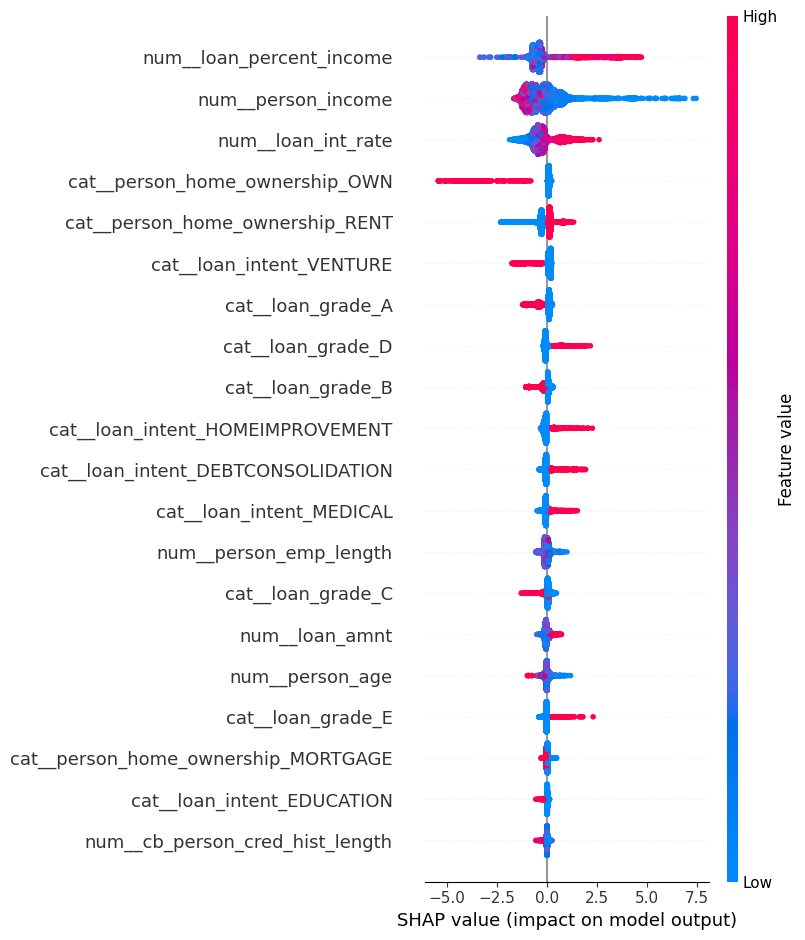

In [ ]:
shap.summary_plot(shap_values, x_test_df)

# **Local Explaination**

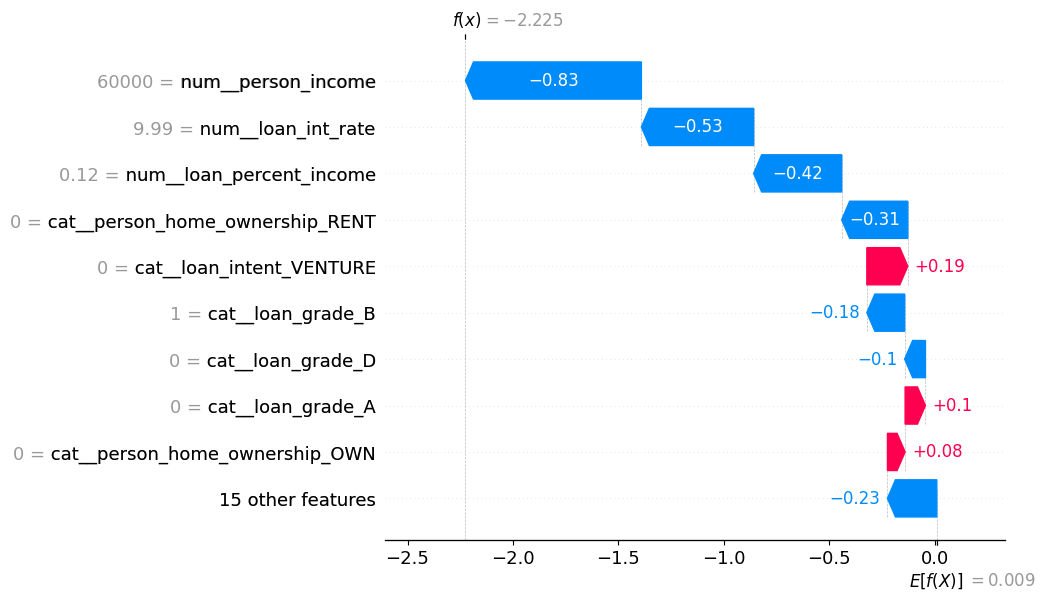

In [ ]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = x_test_df.iloc[row_index],
        feature_names = feature_names
    )
)


# **Analyzing False Positive and False Negative**

In [ ]:
# get predictions from the best performing XGboost model on the test set

y_pred= random_search.predict(x_test)


In [ ]:
# create a dataframe to easily compare the actual and predicted values

result_df=x_test.copy()
result_df['actual']=y_test
result_df['predicted']=y_pred

result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,1
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [ ]:
# identify false positive : Model predicted 1,but the actual was 0

false_positive=result_df[(result_df['actual']==0) & (result_df['predicted']==1)]
false_positive

# identify false negative : Model predicted 0,but the actual was 1
false_negative=result_df[(result_df['actual']==1) & (result_df['predicted']==0)]
false_negative


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
8642,23,53950,MORTGAGE,8.0,EDUCATION,E,15000,16.63,0.28,Y,2,1,0
5615,23,39325,MORTGAGE,3.0,EDUCATION,C,2800,12.87,0.07,N,4,1,0
23959,35,62000,MORTGAGE,9.0,HOMEIMPROVEMENT,B,13000,9.25,0.21,N,10,1,0
4305,23,52000,RENT,5.0,PERSONAL,D,4600,14.96,0.09,N,2,1,0
23499,30,52576,RENT,3.0,HOMEIMPROVEMENT,A,8400,7.49,0.16,N,6,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32426,66,40000,RENT,2.0,EDUCATION,E,7000,15.68,0.17,Y,29,1,0
27976,32,31000,RENT,0.0,EDUCATION,B,5000,11.49,0.16,N,8,1,0
10520,26,52703,MORTGAGE,5.0,MEDICAL,B,4000,11.89,0.06,N,4,1,0
19389,34,30857,RENT,6.0,VENTURE,C,3000,13.06,0.10,N,9,1,0


In [ ]:
print("false positive ",len(false_positive))
print("false negative ",len(false_negative))

false positive  289
false negative  255


# **Save Model**

In [ ]:
import joblib

joblib.dump(calibrated_model,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [ ]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']